## Notebook following the prescription of Ruiz-Zapatero et al. to generate a GP prior 

### **Step 1.** Generating the ensemble of plausible $n(z)$ realizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import euclidlib as el
import nz_prior as nzp
from nz_prior import PriorGP
import matplotlib as mpl
from scipy import integrate
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)
import sys
import os

import euclidlib as el
import seaborn as sns
 
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.serif'] = "Times New Roman"
mpl.rcParams['text.usetex'] = True

In [2]:
# Loading the original n(z) 

z, nz = el.phz.redshift_distributions('/home/jipdebuck/nzTabSPV3.fits')
zs = np.linspace(1e-4, 3, 100)

def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz, z)
dndz_she_norm = normalize_dndz(nz, z)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z, zs)

# Configuration
# This option controls how dense the prior covariance matrix will be.
# "None" means no cross-correlations between any of the parameters (diagonal covariance matrix).
# "BinWise" means cross-correlations only between parameters of the same tomographic bin (block-diagonal covariance matrix).
# "Full" means all parameters are correlated (full covariance matrix).
crosscorrs_method = "BinWise" # "None", "BinWise" or "Full"

In [36]:
# Generating the ensemble

from scipy.ndimage import gaussian_filter1d

def generate_bin1_ensemble(
    N_ens=5,
    z_lo=0.001,
    z_hi=6,
    N_z=3001,
    mean_shift_sigma=0.03,
    width_shift_sigma=0.07,
    shape_noise_sigma=0.25,
    cat_frac=0.05,
    cat_shift=0.02,
    smooth_scale=1,
    nz = dndz_she_norm[1]
):
    """
    Generate an ensemble of n(z) realisations for the FIRST bin only:
        z ∈ [0.001, 0.42]
    using small shifts + smooth perturbations.
    """

    # ---------------------------
    # 1. Grid + base bin n(z)
    # ---------------------------
    z = np.linspace(z_lo, z_hi, N_z)
    nz /= np.trapezoid(nz, z)        # ensure norm within [0, 3] part
    nz_bin = nz.copy()               # for first bin, that's it

    # ---------------------------
    # Build ensemble
    # ---------------------------
    ensemble = []

    z_mean = np.trapezoid(z * nz_bin, z)

    for _ in range(N_ens):

        # Mean shift
        dz = np.random.normal(0, mean_shift_sigma) * z_mean
        z_shift = np.clip(z + dz, z_lo, z_hi)

        # Width/stretch shift
        width = 1 + np.random.normal(0, width_shift_sigma)
        z_stretch = z_mean + width * (z_shift - z_mean)
        z_stretch = np.clip(z_stretch, z_lo, z_hi)

        # Smooth random shape fluctuation
        noise = np.random.normal(0, shape_noise_sigma, N_z)
        noise_smooth = gaussian_filter1d(noise, smooth_scale)
        nz_pert = nz_bin * (1 + noise_smooth)
        nz_pert = np.clip(nz_pert, 1e-12, None)

        # Catastropic outliers
        if np.random.rand() < cat_frac:
            shift_bins = int(cat_shift / (z[1] - z[0]))
            nz_pert = np.roll(nz_pert, shift_bins)


        # Interpolate to shifted grid
        nz_new = np.interp(z, z_stretch, nz_pert, left=0, right=0)

        # Normalise inside the bin
        nz_new /= np.trapezoid(nz_new, z)

        ensemble.append(nz_new)

    return z, np.array(ensemble)

z_ens_list, nz_ensemble_list = zip(*[
    generate_bin1_ensemble(
        N_ens=900, 
        nz=dndz_she_norm[i], 
        N_z=3001
    )
    for i in range(1, 14)
])

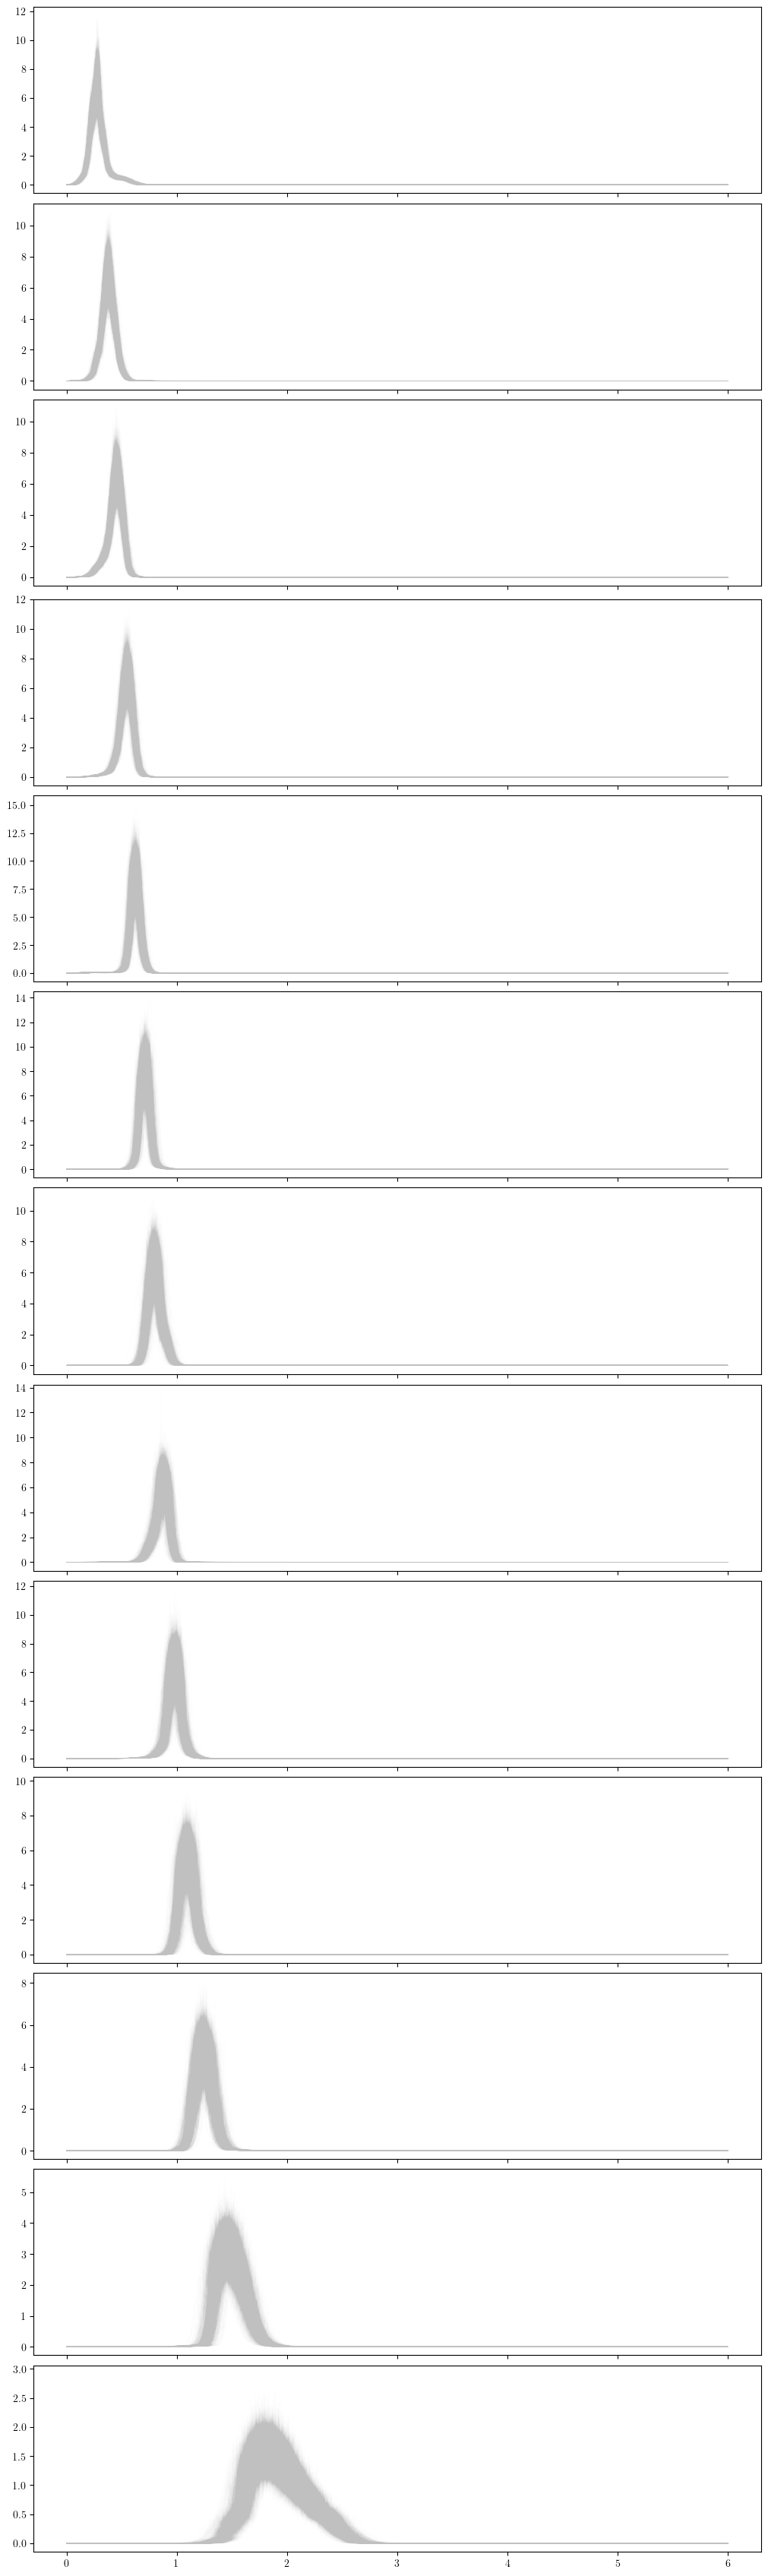

In [39]:
# Plotting the ensemble

import seaborn as sns

n_bins = 13
palette = sns.color_palette("mako", n_bins)

fig, axes = plt.subplots(
    n_bins, 1,
    figsize=(10, 2.6 * n_bins),
    sharex=True,
    constrained_layout=True
)
z_grid = z_ens_list[0]

for b in range(n_bins):
    ax = axes[b]
    arr = nz_ensemble_list[b]

    # --- Original ensemble (thin dashed)
    for i in range(arr.shape[0]):
        ax.plot(z_grid,
                arr[i] / np.trapezoid(arr[i], z_grid),
                color="silver", alpha=0.01, lw=0.8)
        

### **Step 2.** Computing the GP prior from the ensemble

0
Removed no burn in
Removed no burn in
1
Removed no burn in
Removed no burn in
2
Removed no burn in
Removed no burn in
3
Removed no burn in
Removed no burn in
4
Removed no burn in
Removed no burn in
5
Removed no burn in
Removed no burn in
6
Removed no burn in
Removed no burn in
7
Removed no burn in
Removed no burn in
8
Removed no burn in
Removed no burn in
9
Removed no burn in
Removed no burn in
10
Removed no burn in
Removed no burn in
11
Removed no burn in
Removed no burn in
12
Removed no burn in
Removed no burn in


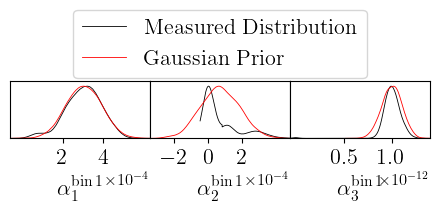

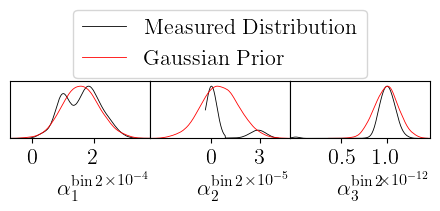

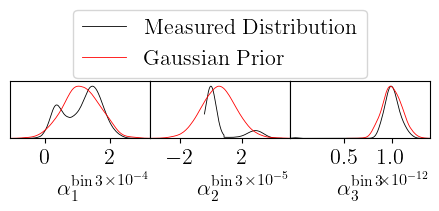

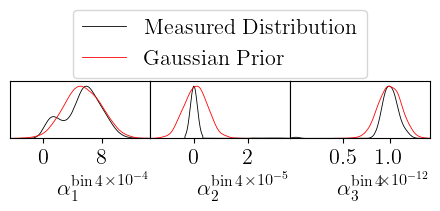

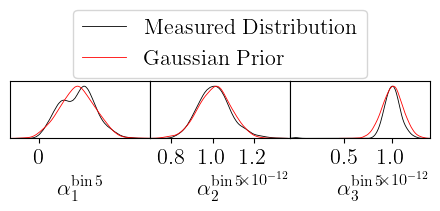

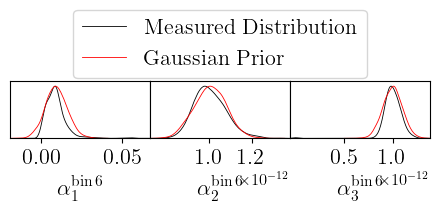

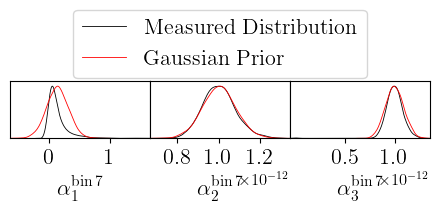

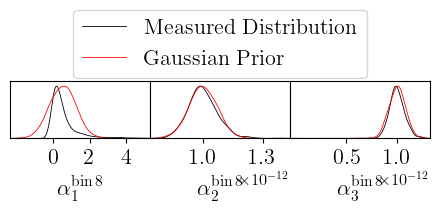

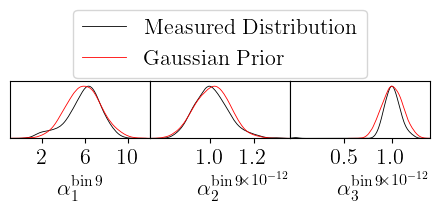

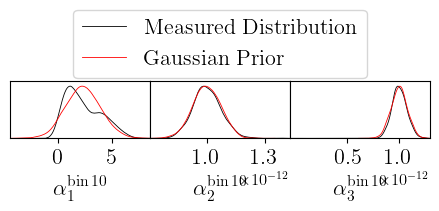

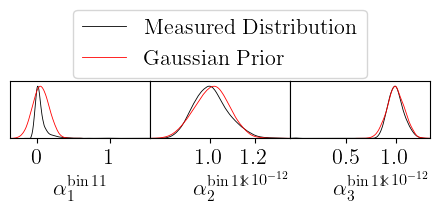

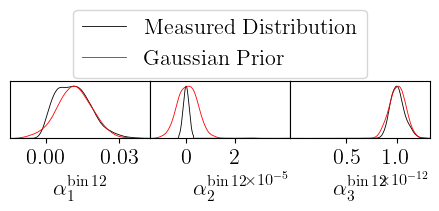

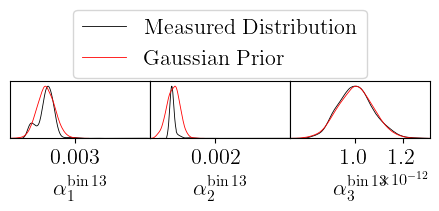

In [40]:
gp_bins = []
for i in range(len(z_ens_list)):
    print(i)
    gp = PriorGP([z_ens_list[i], nz_ensemble_list[i]], nparams=3)
    gp_bins.append(gp)
    labels = [f"$\\alpha_{{{k}}}^{{\\rm bin\\,{i+1}}}$" for k in range(1, 4)]
    gp.plot_prior(mode="1D", add_prior=True, labels=labels)


### **Step 3.** Drawing samples from the prior

In [ ]:
gp_nzs = {}

for i, gp in enumerate(gp_bins):

    z = gp.z
    nz_mean = gp.nz_mean

    prior_mean, prior_cov, prior_chol = gp.get_prior()

    W = gp.funcs @ prior_chol


    nparams = gp.nparams
    nz_samples = np.array([
        nzp.linear_model(nz_mean, W, np.random.randn(nparams))
        for _ in range(200)
    ])

    gp_nzs[f"bin_{i+1}"] = [z, nz_samples]


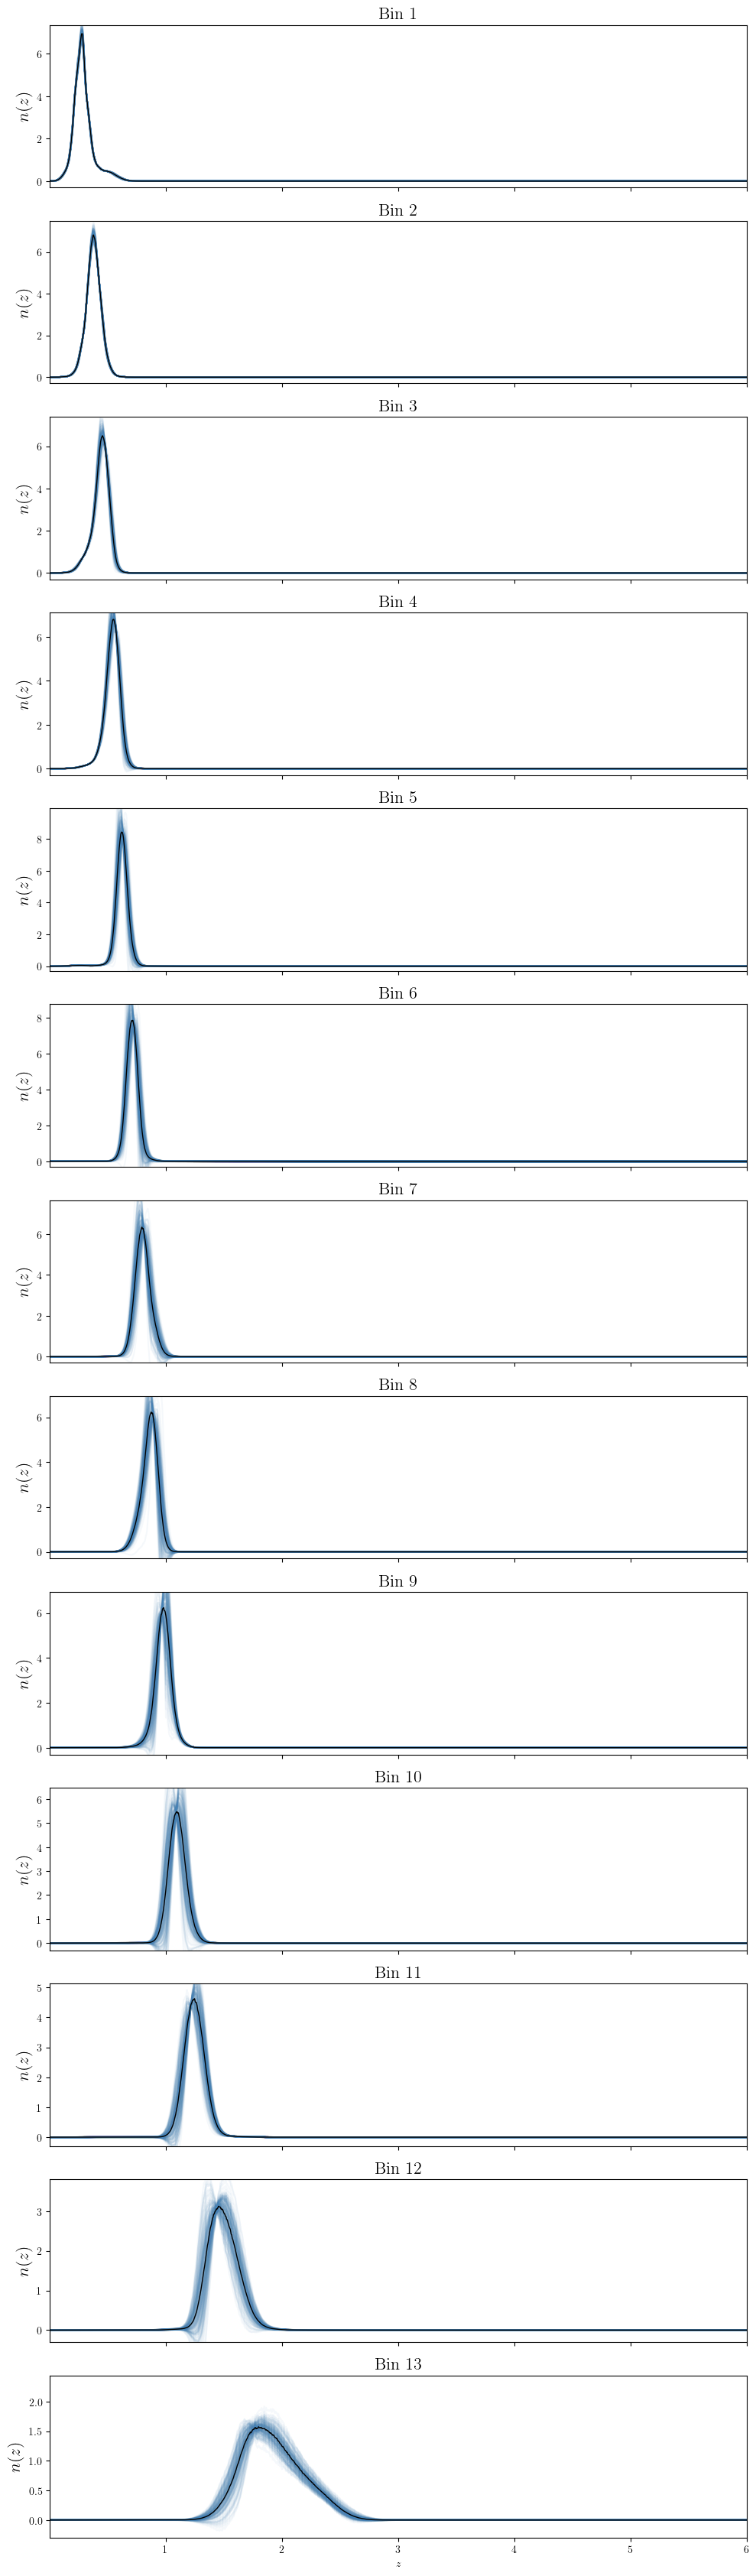

In [ ]:
fig, axes = plt.subplots(
    13, 1,
    figsize=(10, 2.6*13),     
    sharex=True          
)

axes = axes.flatten()

for i, (name, (z, nz_samples)) in enumerate(gp_nzs.items()):
    
    for nz in nz_samples:
        axes[i].plot(z, nz, color='steelblue', alpha=0.05)
    
    axes[i].plot(z, nz_samples.mean(axis=0), color='black', lw=1)
    
    axes[i].set_title(f"Bin {i+1}", fontsize=16)
    axes[i].set_ylabel("$n(z)$", fontsize=16)
    axes[i].set_xlim(min(z), max(z))
    axes[i].set_ylim(-0.3, max(nz_samples[0]+0.7))

axes[-1].set_xlabel("$z$")


for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()




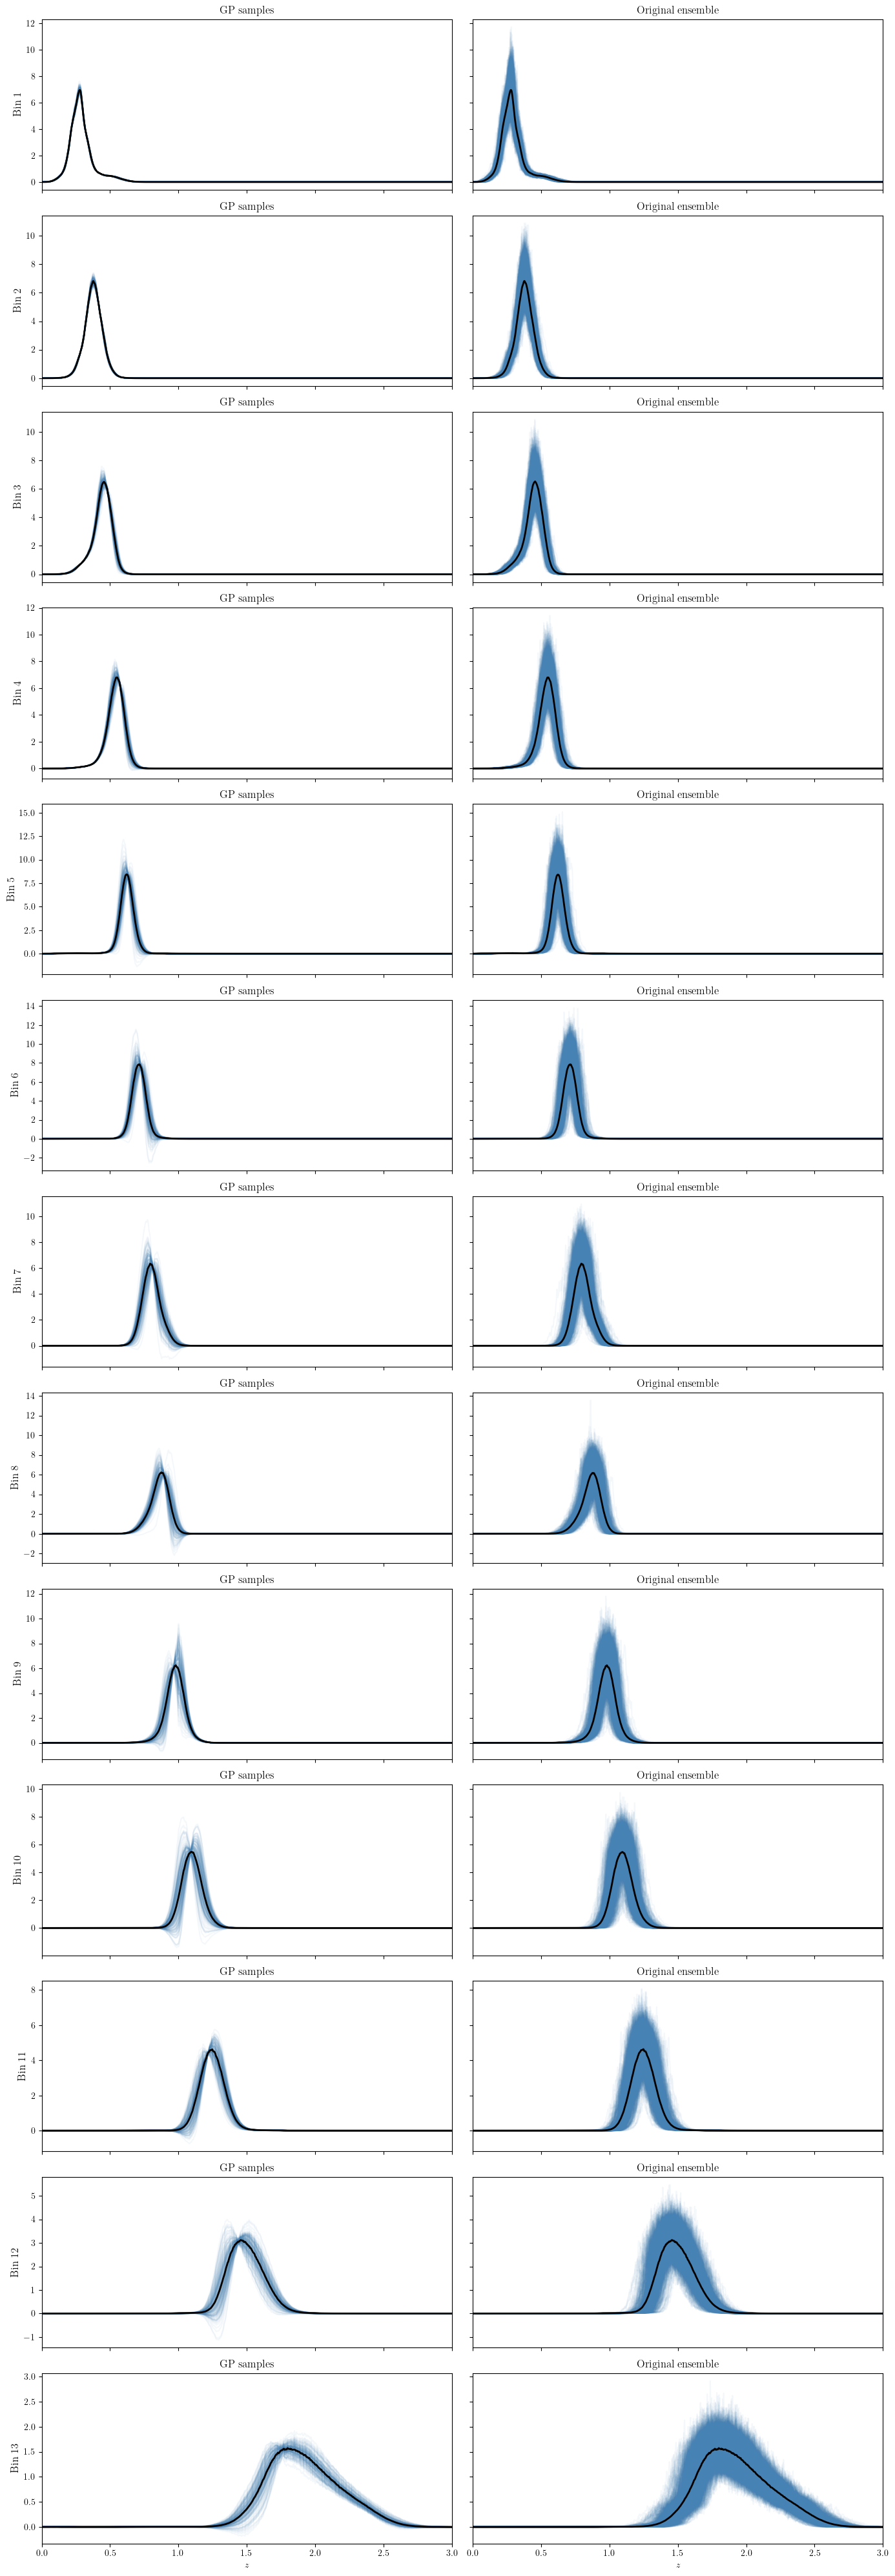

In [ ]:
fig, axes = plt.subplots(
    13, 2,
    figsize=(14, 40),   # tall figure for 13 rows
    sharex='col',       # share x-axis within each column
    sharey='row'        # share y-axis within each row
)

for i, (name, (z_gp, nz_gp)) in enumerate(gp_nzs.items()):

    ax_left = axes[i, 0]
    for nz in nz_gp[:200]: 
        ax_left.plot(z_gp, nz, color='steelblue', alpha=0.05)
    ax_left.plot(z_gp, nz_gp.mean(axis=0), color='black', lw=2)
    ax_left.set_ylabel(f"Bin {i+1}", fontsize=12)
    if i == 12:
        ax_left.set_xlabel("$z$")
    ax_left.set_title("GP samples")
    ax_left.set_xlim(0,3)

    ax_right = axes[i, 2-1]   # same as axes[i,1]
    z_orig, nz_orig = z_ens_list[i], nz_ensemble_list[i]   
    for nz in nz_orig:
        ax_right.plot(z_orig, nz, color='steelblue', alpha=0.05)
    ax_right.plot(z_orig, nz_orig.mean(axis=0), color='black', lw=2)
    if i == 12:
        ax_right.set_xlabel("$z$")
    ax_right.set_title("Original ensemble")
    ax_right.set_xlim(0,3)

plt.tight_layout()
plt.show()